# SCP259 初步分析
结肠组织样本，68个样本  (包含上皮层和固有层)
28UC，40HC
- UC38-UC65
- HC47-HC86

# 文件说明
- **文件名**: 8_SCP259.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-25  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/8_SCP259_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


In [2]:
!pwd

/home/future/UC_Treg_Project/notebooks/1_preprocessing


## 读取数据

In [3]:
adata = sc.read_h5ad('/mnt/e/UC/scRNA-seq_RAW/8_SCP259/combined.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 115516 × 19446
    obs: 'nGene', 'nUMI', 'Subject', 'Location', 'Sample', 'Cluster', 'Health'
    var: 'features'

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
adata

AnnData object with n_obs × n_vars = 115516 × 19446
    obs: 'nGene', 'nUMI', 'Subject', 'Location', 'Sample', 'Cluster', 'Health', 'n_genes'
    var: 'features', 'n_cells'

In [7]:
adata.obs.head()

,nGene,nUMI,Subject,Location,Sample,Cluster,Health,n_genes
Fib_N10.EpiA.AACATATGGGGATG,791,1523.0,N10,Epi,N10.EpiA,WNT5B+ 2,Healthy,791
Fib_N10.LPA.AAACATACTCGATG,905,2108.0,N10,LP,N10.LPA,WNT2B+ Fos-hi,Healthy,905
Fib_N10.LPA.AAACGCACCTTATC,682,1435.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,682
Fib_N10.LPA.AAACGCACTGGCAT,973,2200.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,973
Fib_N10.LPA.AAACGCTGGTTTGG,459,752.0,N10,LP,N10.LPA,Pericytes,Healthy,459


In [8]:
import pandas as pd

# 查看 Sample 对应的 Health 列
sample_health = adata.obs[["Sample", 'Health']]

# 去重，只保留每个 Sample 的一个 Health 状态
sample_health_unique = sample_health.drop_duplicates()

print(sample_health_unique)

                                 Sample      Health
Fib_N10.EpiA.AACATATGGGGATG    N10.EpiA     Healthy
Fib_N10.LPA.AAACATACTCGATG      N10.LPA     Healthy
Fib_N10.LPB.AAACATACATGTCG      N10.LPB     Healthy
Fib_N11.LPA.AAACGGCTGCCAAT      N11.LPA     Healthy
Fib_N11.LPB.AAAGACGAGGGAGT      N11.LPB     Healthy
...                                 ...         ...
Imm_N26.EpiB.AAGACCTGTTTACTCT  N26.EpiB    Inflamed
Imm_N7.EpiA.AAGGTGCTACGGAG      N7.EpiA  Uninflamed
Imm_N7.EpiB.AAAGTTTGTGTGCA      N7.EpiB    Inflamed
Imm_N8.EpiA.AGCGAACTCTGTGA      N8.EpiA     Healthy
Epi_N8.EpiB.AAAGTTTGACCCTC      N8.EpiB     Healthy

[68 rows x 2 columns]


In [22]:
sample_health_unique.to_csv("/mnt/e/UC/scRNA-seq_RAW/8_SCP259/sample_health_mapping.csv", index=False)

In [9]:
# 1️⃣ 创建 Sample → id 的映射字典
sample_to_id = {
    "N10.EpiA":"HC47", "N10.LPA":"HC48", "N10.LPB":"HC49",
    "N11.LPA":"HC50", "N11.LPB":"HC51", "N13.LPA":"HC52",
    "N13.LPB":"HC53", "N15.EpiA":"HC54", "N15.LPA":"HC55",
    "N15.LPB":"HC56", "N16.LPA":"HC57", "N16.LPB":"HC58",
    "N17.EpiB":"HC59", "N17.LPA":"HC60", "N17.LPB":"HC61",
    "N18.EpiB":"HC62", "N18.LPA":"HC63", "N18.LPB":"HC64",
    "N20.LPA":"HC65", "N20.LPB":"HC66", "N21.LPA":"HC67",
    "N21.LPB":"HC68", "N8.LPA":"HC69", "N8.LPB":"HC70",
    "N10.EpiB":"HC71", "N11.EpiA":"HC72", "N11.EpiB":"HC73",
    "N13.EpiA":"HC74", "N13.EpiB":"HC75", "N15.EpiB":"HC76",
    "N16.EpiA":"HC77", "N16.EpiB":"HC78", "N17.EpiA":"HC79",
    "N18.EpiA":"HC80", "N20.EpiA":"HC81", "N20.EpiB":"HC82",
    "N21.EpiA":"HC83", "N21.EpiB":"HC84", "N8.EpiA":"HC85",
    "N8.EpiB":"HC86", "N12.LPB":"UC38", "N14.LPB":"UC39",
    "N19.LPB":"UC40", "N23.LPB":"UC41", "N26.LPB":"UC42",
    "N7.LPB":"UC43", "N9.EpiB":"UC44", "N9.LPB":"UC45",
    "N12.EpiB":"UC46", "N14.EpiB":"UC47", "N19.EpiB":"UC48",
    "N23.EpiB":"UC49", "N26.EpiB":"UC50", "N7.EpiB":"UC51",
    "N12.LPA":"UC52", "N14.LPA":"UC53", "N19.LPA":"UC54",
    "N23.LPA":"UC55", "N26.EpiA":"UC56", "N26.LPA":"UC57",
    "N7.LPA":"UC58", "N9.EpiA":"UC59", "N9.LPA":"UC60",
    "N12.EpiA":"UC61", "N14.EpiA":"UC62", "N19.EpiA":"UC63",
    "N23.EpiA":"UC64", "N7.EpiA":"UC65"
}

# 2️⃣ 根据 Sample 列生成 id 列
adata.obs['id'] = adata.obs['Sample'].map(sample_to_id)

# 3️⃣ 查看前几行确认
print(adata.obs[['Sample','id','Health']].head())

                               Sample    id   Health
Fib_N10.EpiA.AACATATGGGGATG  N10.EpiA  HC47  Healthy
Fib_N10.LPA.AAACATACTCGATG    N10.LPA  HC48  Healthy
Fib_N10.LPA.AAACGCACCTTATC    N10.LPA  HC48  Healthy
Fib_N10.LPA.AAACGCACTGGCAT    N10.LPA  HC48  Healthy
Fib_N10.LPA.AAACGCTGGTTTGG    N10.LPA  HC48  Healthy


In [10]:
adata.obs['id'].value_counts()

id
HC49    4930
HC48    4456
UC59    4343
HC71    3813
UC64    3749
        ... 
HC50     292
UC61     261
UC51     194
HC86     175
UC46      60
Name: count, Length: 68, dtype: int64

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [11]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||---------------------------- 1216/16311 MiB (7.5%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 115,516 cells × 19,446 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 36 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2275 (range: 306-5482)
     • Mean genes: 1060 (range: 249-9074)
     • Mean mitochondrial %: 2.9% (max: 37.2%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 21 cells failed (0.0%)
     • Genes filter (≥250): 145 cells failed (0.1%)
     • Mitochondrial filter (≤0.2): 52 cells failed (0.0%)
   ✓ Combined QC filters: 195 cells removed (0.2%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_c

: 

## 保存质控后数据（去除双细胞）


In [ ]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "8_SCP259.h5ad"), compression='gzip')

In [10]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 14314/14314 genes are kept.     Among 14314 genes, 14314 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['GUCA2B', 'IGKC', 'JCHAIN', 'HBB', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHG2', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'HBA2', 'ZG16', 'PYY', 'FTL', 'IGLC1', 'IGLC2', 'IGLC3', 'IGLC7']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 3.0809574127197266 seconds.
End

In [11]:
adata

AnnData object with n_obs × n_vars = 44266 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

指控后每个样本细胞数

In [12]:
adata.obs['id'].value_counts()

id
UC35    5766
HC40    4786
HC42    4640
HC46    4414
UC37    4353
HC45    4274
HC43    4037
UC36    3413
HC44    3151
HC39    2665
HC41    2133
UC34     634
Name: count, dtype: int64

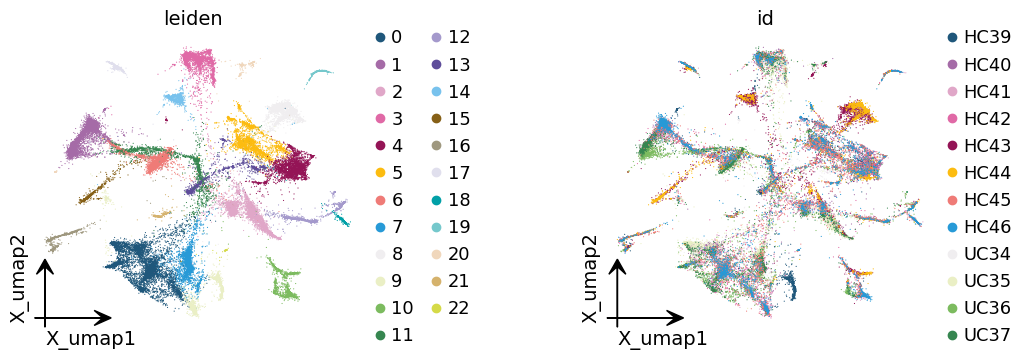

In [13]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

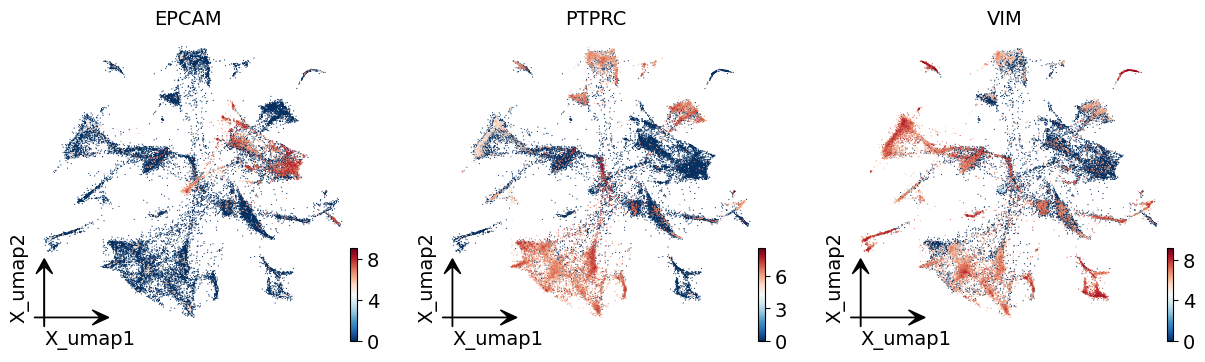

In [14]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

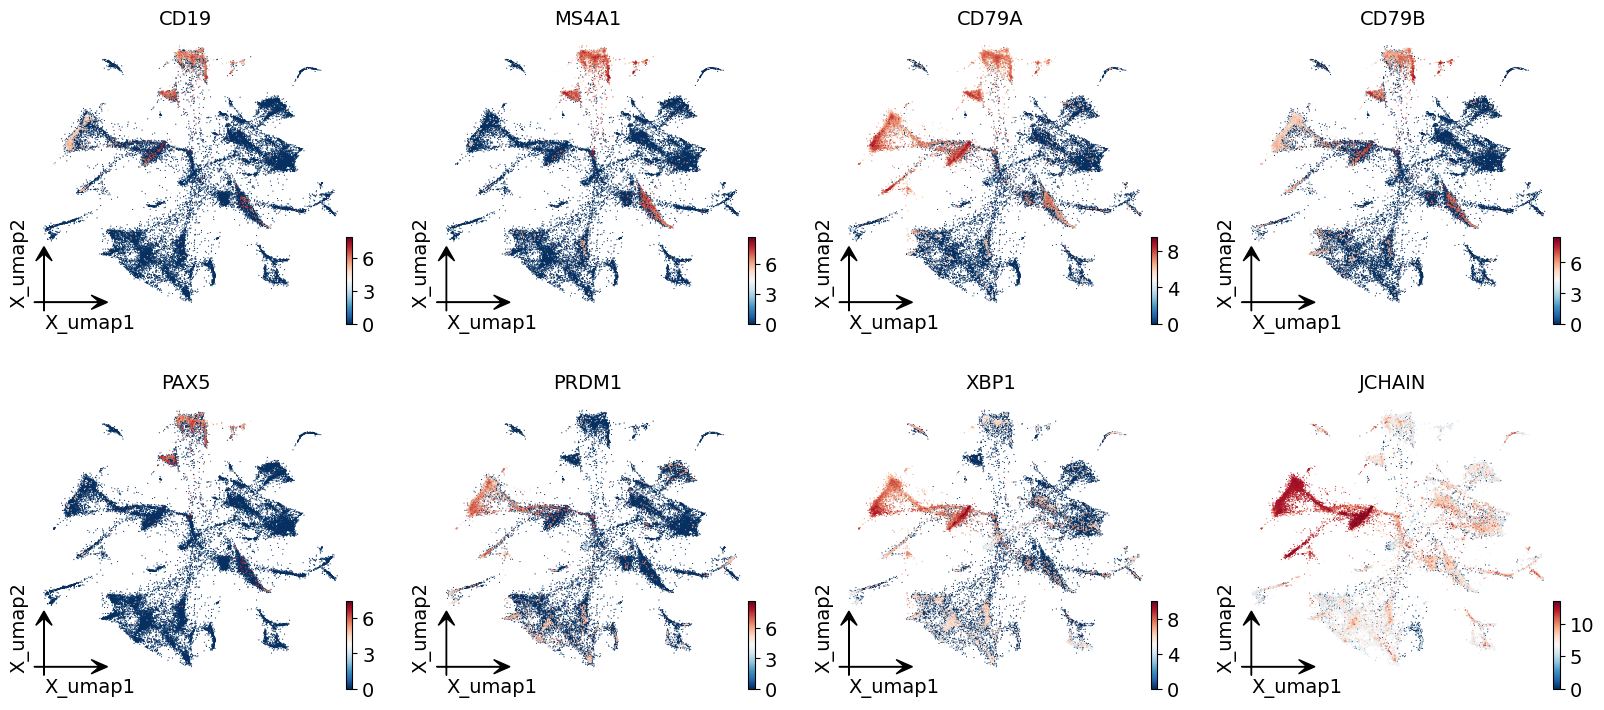

In [15]:
# 查看B细胞和浆细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'PRDM1', 'XBP1', 'JCHAIN'],
                frameon='small')

## GPT自动注释

In [16]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:14)


{'0': ['CD2',
  'SARAF',
  'CD3D',
  'TRAC',
  'BTG1',
  'SRGN',
  'IL32',
  'CREM',
  'KLRB1',
  'CD3E'],
 '1': ['SSR4',
  'DERL3',
  'TXNDC5',
  'XBP1',
  'HERPUD1',
  'UBE2J1',
  'MZB1',
  'SEC11C',
  'JCHAIN',
  'FKBP11'],
 '10': ['COL3A1',
  'C1S',
  'CALD1',
  'IFITM3',
  'LUM',
  'C1R',
  'DCN',
  'ADAMDEC1',
  'CXCL14',
  'COL1A2'],
 '11': ['IGHA1',
  'MT-ND1',
  'MT-ATP6',
  'MT-ND5',
  'MT-CYB',
  'MT-ND2',
  'MT-ND4',
  'MALAT1',
  'MT-CO1',
  'MT-ND3'],
 '12': ['FTL',
  'LYZ',
  'HLA-DPA1',
  'HLA-DRB1',
  'TYROBP',
  'CD74',
  'AIF1',
  'HLA-DRA',
  'TMSB4X',
  'HLA-DPB1'],
 '13': ['PIGR',
  'FAM3D',
  'CLDN4',
  'SPINK1',
  'S100A6',
  'KRT18',
  'AGR2',
  'LGALS4',
  'KRT8',
  'TFF3'],
 '14': ['CD37',
  'HLA-DPA1',
  'HLA-DRB1',
  'HLA-DQA1',
  'CXCR4',
  'HLA-DQB1',
  'CD74',
  'CD79A',
  'HLA-DRA',
  'HLA-DPB1'],
 '15': ['SPCS2',
  'SSR4',
  'SEC61B',
  'SPCS1',
  'TNFRSF17',
  'IGHA2',
  'MZB1',
  'SEC11C',
  'JCHAIN',
  'UBC'],
 '16': ['CRIP2',
  'CAV1',
  'TM4SF1',


In [17]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'T cell',
 '1': 'Plasma cell',
 '10': 'Fibroblast',
 '11': 'Plasma cell',
 '12': 'Myeloid cell',
 '13': 'Enterocyte',
 '14': 'B cell',
 '15': 'Plasma cell',
 '16': 'Endothelial cell',
 '17': 'Mast cell',
 '18': 'Enterocyte',
 '19': 'Oligodendrocyte',
 '2': 'Proliferating cell',
 '20': 'B cell',
 '21': 'Pericyte',
 '22': 'T cell',
 '3': 'Dendritic cell',
 '4': 'Enterocyte',
 '5': 'Enterocyte',
 '6': 'Plasma cell',
 '7': 'NK cell',
 '8': 'T cell',
 '9': 'T cell'}

In [ ]:
#os.environ['AGI_API_KEY'] = 'sk-p0VgGvztXDK2erOoUul7cHcSDt4UduGk6f8voA0zn1F1L5xe'
#result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='moonshot-v1-8k',
                               provider='kimi',
                               topgenenumber=10)
#result

In [18]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

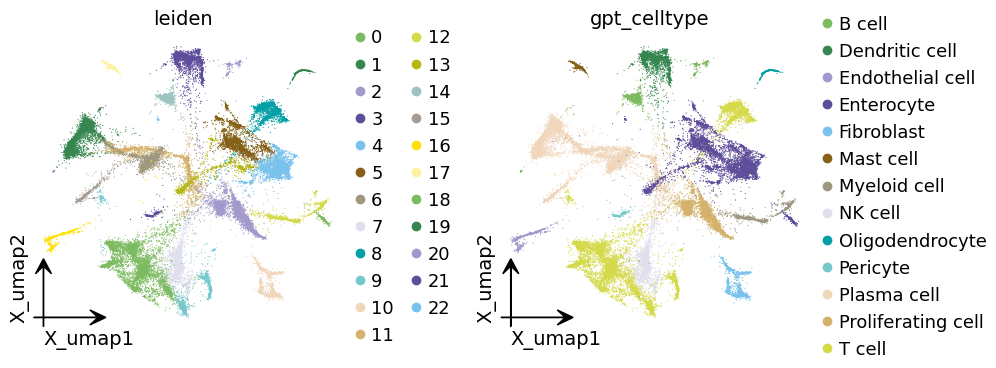

In [19]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [20]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
T cell                22.895676
Plasma cell           22.525189
Enterocyte            16.190756
Proliferating cell     8.387928
Dendritic cell         7.120589
NK cell                5.523427
Fibroblast             4.172503
B cell                 3.980482
Myeloid cell           3.356978
Endothelial cell       2.315547
Mast cell              1.845660
Oligodendrocyte        1.039172
Pericyte               0.646094
Name: proportion, dtype: float64
